In [24]:
!pip install snowflake-connector-python

In [25]:
import pandas as pd
import snowflake.connector

conn = snowflake.connector.connect(
    user='RAHUL28',
    password='Rahul@28112006',
    account='fmfpcxc-ly07437',
    database='GENDERCLASSIFICATION',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

print("Connection Successful")


Connection Successful


In [26]:
query='select * from Gender'
df=pd.read_sql(query,conn)

conn.close()

print(df.head())

/tmp/ipykernel_2265/2679517883.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


   LONG_HAIR  FOREHEAD_WIDTH_CM  FOREHEAD_HEIGHT_CM  NOSE_WIDE  NOSE_LONG  \
0          1               11.8                 6.1          1          0   
1          0               14.0                 5.4          0          0   
2          0               11.8                 6.3          1          1   
3          0               14.4                 6.1          0          1   
4          1               13.5                 5.9          0          0   

   LIPS_THIN  DISTANCE_NOSE_TO_LIP_LONG  GENDER  
0          1                          1    Male  
1          1                          0  Female  
2          1                          1    Male  
3          1                          1    Male  
4          0                          0  Female  


In [27]:
df.tail()

,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female
5000,1,15.4,5.4,1,1,1,1,Male


In [28]:
df.isnull().sum()

,0
LONG_HAIR,0
FOREHEAD_WIDTH_CM,0
FOREHEAD_HEIGHT_CM,0
NOSE_WIDE,0
NOSE_LONG,0
LIPS_THIN,0
DISTANCE_NOSE_TO_LIP_LONG,0
GENDER,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   LONG_HAIR                  5001 non-null   int64  
 1   FOREHEAD_WIDTH_CM          5001 non-null   float64
 2   FOREHEAD_HEIGHT_CM         5001 non-null   float64
 3   NOSE_WIDE                  5001 non-null   int64  
 4   NOSE_LONG                  5001 non-null   int64  
 5   LIPS_THIN                  5001 non-null   int64  
 6   DISTANCE_NOSE_TO_LIP_LONG  5001 non-null   int64  
 7   GENDER                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [30]:
import seaborn as sns

df.shape

(5001, 8)

In [31]:
df.describe()

,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


<Axes: >

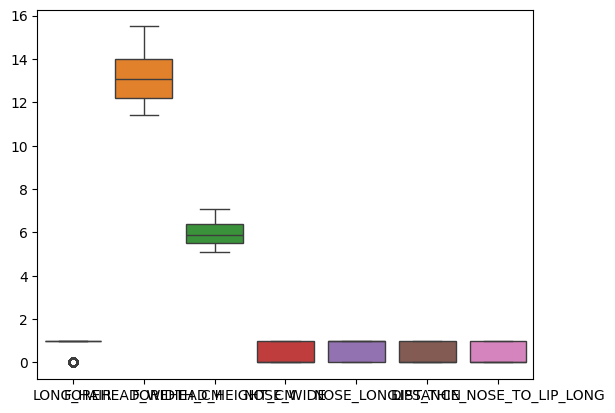

In [32]:
sns.boxplot(df)

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df

,LONG_HAIR,FOREHEAD_WIDTH_CM,FOREHEAD_HEIGHT_CM,NOSE_WIDE,NOSE_LONG,LIPS_THIN,DISTANCE_NOSE_TO_LIP_LONG,GENDER
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


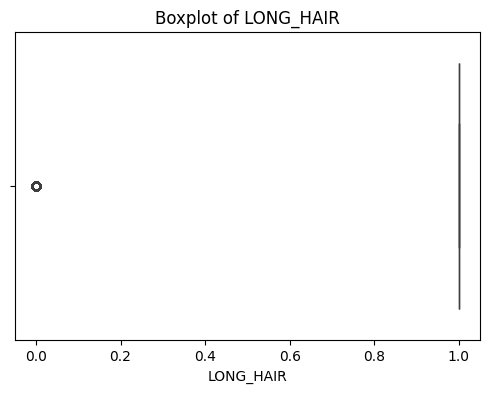

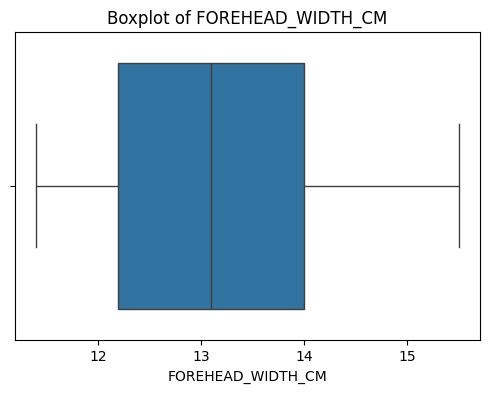

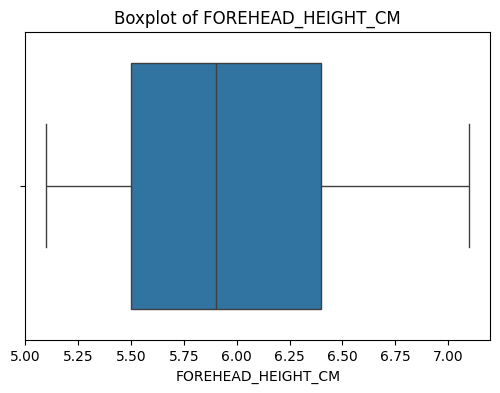

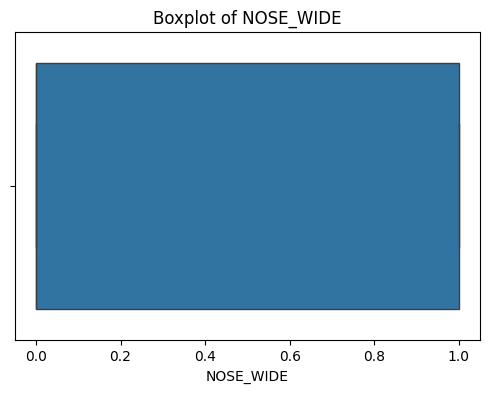

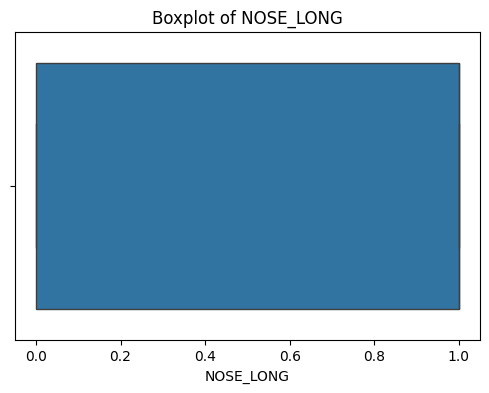

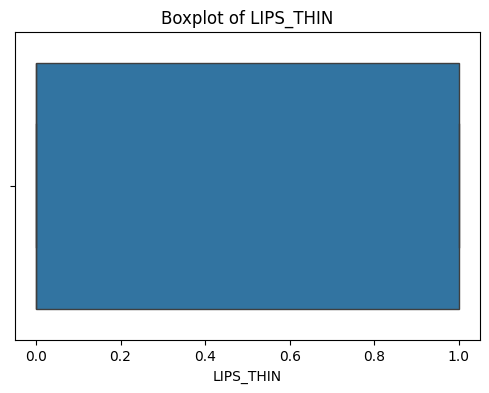

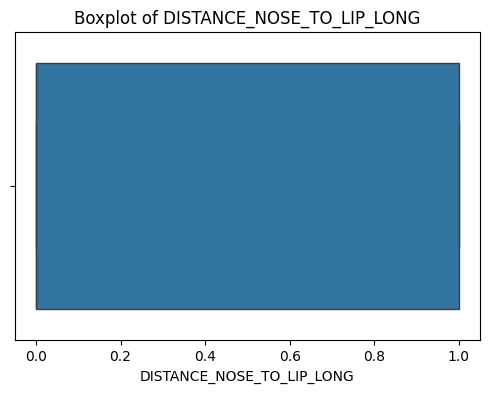

In [34]:
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [35]:
X = df.drop('GENDER', axis=1)
y = df['GENDER']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=1)
model=DecisionTreeClassifier(ccp_alpha=0.01)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.961038961038961


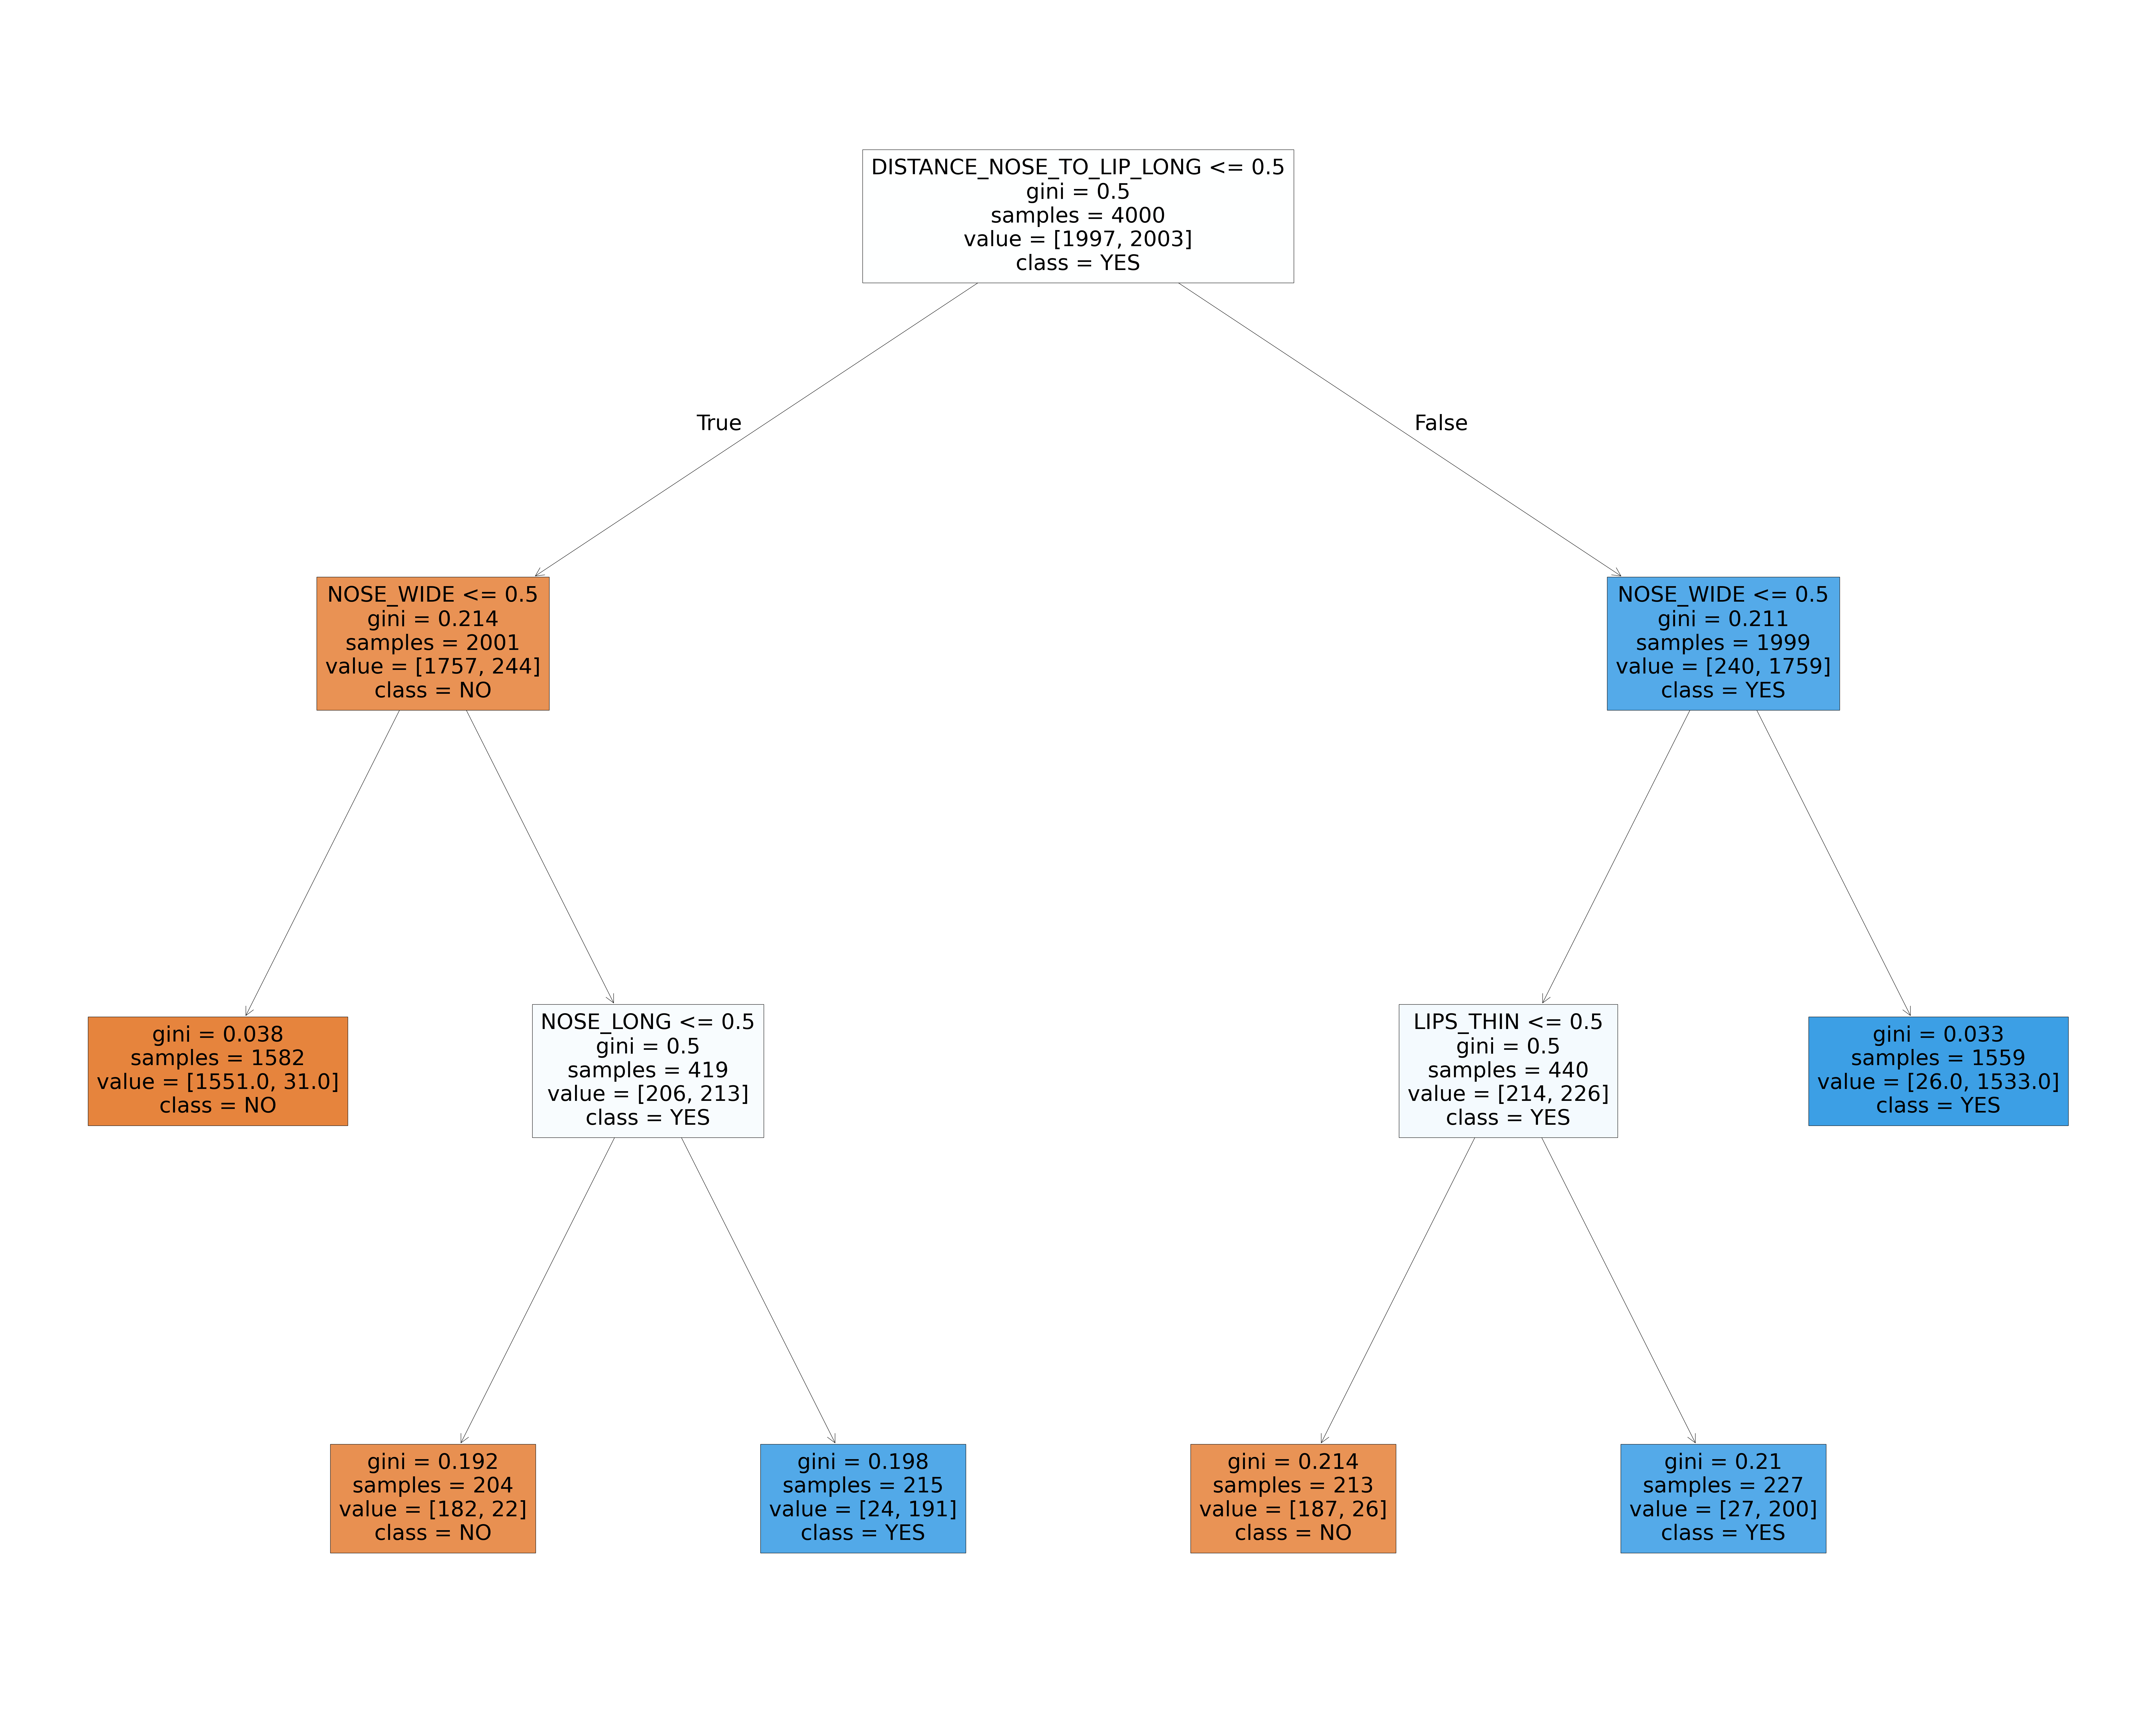

In [40]:
from sklearn import tree
plt.figure(figsize=(100,80))
tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['NO', 'YES']
)

plt.show()